# MIND Dataset Exploration
## Microsoft News Dataset for News Recommendation

This notebook explores the MIND (Microsoft News Dataset) to understand:
- Dataset structure and format
- User behavior patterns
- News article characteristics
- Interaction sparsity
- Temporal patterns

In [4]:
# Verify Python Environment
import sys
print("Python version:", sys.version)
print("Python executable:", sys.executable)
print("\nEnvironment is working correctly!")

Python version: 3.13.7 (v3.13.7:bcee1c32211, Aug 14 2025, 19:10:51) [Clang 16.0.0 (clang-1600.0.26.6)]
Python executable: /Users/vaishnavikamdi/Documents/GWU/Classes/Fall 2025/AdvML/HW2/.venv/bin/python

Environment is working correctly!


In [5]:
# Import necessary libraries
import zipfile
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Extract Dataset Files

In [6]:
# Define paths
base_path = '/Users/vaishnavikamdi/Documents/GWU/Classes/Fall 2025/AdvML/HW2'
data_path = os.path.join(base_path, 'data')

# Paths to the extracted data folders
train_dir = os.path.join(data_path, 'MINDsmall_train')
dev_dir = os.path.join(data_path, 'MINDsmall_dev')

# Verify directories exist
if not os.path.exists(train_dir):
    raise FileNotFoundError(f"Training directory not found: {train_dir}")
if not os.path.exists(dev_dir):
    raise FileNotFoundError(f"Dev directory not found: {dev_dir}")

print("Data directories located successfully!")
print(f"Training data: {train_dir}")
print(f"Dev data: {dev_dir}")

# List files in extracted directories
print("\n" + "="*50)
print("Files in training directory:")
for file in sorted(os.listdir(train_dir)):
    filepath = os.path.join(train_dir, file)
    if os.path.isfile(filepath):
        size_mb = os.path.getsize(filepath) / (1024 * 1024)
        print(f"  - {file} ({size_mb:.2f} MB)")

print("\nFiles in dev directory:")
for file in sorted(os.listdir(dev_dir)):
    filepath = os.path.join(dev_dir, file)
    if os.path.isfile(filepath):
        size_mb = os.path.getsize(filepath) / (1024 * 1024)
        print(f"  - {file} ({size_mb:.2f} MB)")

Data directories located successfully!
Training data: /Users/vaishnavikamdi/Documents/GWU/Classes/Fall 2025/AdvML/HW2/data/MINDsmall_train
Dev data: /Users/vaishnavikamdi/Documents/GWU/Classes/Fall 2025/AdvML/HW2/data/MINDsmall_dev

Files in training directory:
  - behaviors.tsv (87.76 MB)
  - entity_embedding.vec (24.62 MB)
  - news.tsv (39.29 MB)
  - relation_embedding.vec (1.00 MB)

Files in dev directory:
  - behaviors.tsv (40.85 MB)
  - entity_embedding.vec (20.94 MB)
  - news.tsv (31.97 MB)
  - relation_embedding.vec (1.00 MB)


### Key Findings 

The dataset contains the essential files for news recommendation: 

- `behaviors.tsv` (user interactions),
- `news.tsv` (article metadata), and
- `entity_embedding.vec` (pre-trained embeddings).

The training set is larger (~ 15MB behaviors) compared to dev set (~ 5MB)

## 2. Load and Explore News Data

The `news.tsv` file contains information about news articles with the following columns:
- **News ID**: Unique identifier for the news article
- **Category**: News category (e.g., sports, entertainment, news)
- **SubCategory**: More specific category
- **Title**: Article title
- **Abstract**: Brief summary
- **URL**: Article URL
- **Title Entities**: Named entities in the title
- **Abstract Entities**: Named entities in the abstract

In [7]:
# Load news data from training set
news_columns = ['news_id', 'category', 'subcategory', 'title', 'abstract', 'url', 'title_entities', 'abstract_entities']
news_train = pd.read_csv(os.path.join(train_dir, 'news.tsv'), sep='\t', names=news_columns, header=None)

print("Training News Dataset Shape:", news_train.shape)
print("\nFirst few rows:")
news_train.head()

Training News Dataset Shape: (51282, 8)

First few rows:


,news_id,category,subcategory,title,abstract,url,title_entities,abstract_entities
0,N55528,lifestyle,lifestyleroyals,"The Brands Queen Elizabeth, Prince Charles, and Prince Philip Swear By","Shop the notebooks, jackets, and more that the royals can't live without.",https://assets.msn.com/labs/mind/AAGH0ET.html,"[{""Label"": ""Prince Philip, Duke of Edinburgh"", ""Type"": ""P"", ""WikidataId"": ""Q80976"", ""Confidence""...",[]
1,N19639,health,weightloss,50 Worst Habits For Belly Fat,These seemingly harmless habits are holding you back and keeping you from shedding that unwanted...,https://assets.msn.com/labs/mind/AAB19MK.html,"[{""Label"": ""Adipose tissue"", ""Type"": ""C"", ""WikidataId"": ""Q193583"", ""Confidence"": 1.0, ""Occurrenc...","[{""Label"": ""Adipose tissue"", ""Type"": ""C"", ""WikidataId"": ""Q193583"", ""Confidence"": 1.0, ""Occurrenc..."
2,N61837,news,newsworld,The Cost of Trump's Aid Freeze in the Trenches of Ukraine's War,Lt. Ivan Molchanets peeked over a parapet of sand bags at the front line of the war in Ukraine. ...,https://assets.msn.com/labs/mind/AAJgNsz.html,[],"[{""Label"": ""Ukraine"", ""Type"": ""G"", ""WikidataId"": ""Q212"", ""Confidence"": 0.946, ""OccurrenceOffsets..."
3,N53526,health,voices,I Was An NBA Wife. Here's How It Affected My Mental Health.,"I felt like I was a fraud, and being an NBA wife didn't help that. In fact, it nearly destroyed me.",https://assets.msn.com/labs/mind/AACk2N6.html,[],"[{""Label"": ""National Basketball Association"", ""Type"": ""O"", ""WikidataId"": ""Q155223"", ""Confidence""..."
4,N38324,health,medical,"How to Get Rid of Skin Tags, According to a Dermatologist","They seem harmless, but there's a very good reason you shouldn't ignore them. The post How to Ge...",https://assets.msn.com/labs/mind/AAAKEkt.html,"[{""Label"": ""Skin tag"", ""Type"": ""C"", ""WikidataId"": ""Q3179593"", ""Confidence"": 1.0, ""OccurrenceOffs...","[{""Label"": ""Skin tag"", ""Type"": ""C"", ""WikidataId"": ""Q3179593"", ""Confidence"": 1.0, ""OccurrenceOffs..."


In [8]:
# Basic statistics about news articles
print("="*60)
print("NEWS ARTICLE STATISTICS")
print("="*60)
print(f"\nTotal unique news articles: {news_train['news_id'].nunique():,}")
print(f"Total categories: {news_train['category'].nunique()}")
print(f"Total subcategories: {news_train['subcategory'].nunique()}")
print(f"\nMissing values per column:")
print(news_train.isnull().sum())

print("\n" + "="*60)
print("Top 15 News Categories:")
print("="*60)
category_counts = news_train['category'].value_counts()
for cat, count in category_counts.head(15).items():
    print(f"  {cat:20s}: {count:5,} articles ({count/len(news_train)*100:.1f}%)")

NEWS ARTICLE STATISTICS

Total unique news articles: 51,282
Total categories: 17
Total subcategories: 264

Missing values per column:
news_id                 0
category                0
subcategory             0
title                   0
abstract             2666
url                     0
title_entities          3
abstract_entities       4
dtype: int64

Top 15 News Categories:
  news                : 15,774 articles (30.8%)
  sports              : 14,510 articles (28.3%)
  finance             : 3,107 articles (6.1%)
  foodanddrink        : 2,551 articles (5.0%)
  lifestyle           : 2,479 articles (4.8%)
  travel              : 2,350 articles (4.6%)
  video               : 2,068 articles (4.0%)
  weather             : 2,048 articles (4.0%)
  health              : 1,885 articles (3.7%)
  autos               : 1,639 articles (3.2%)
  tv                  :   889 articles (1.7%)
  music               :   769 articles (1.5%)
  movies              :   606 articles (1.2%)
  entertainment   

### Insights: 

The dataset covers diverse news topics with **news**, **sports**, and **entertainment** being the most prominent categories. The variety in categories (17 total) ensures the recommendation model can learn preferences across different content types, which is crucial for personalized news recommendations.

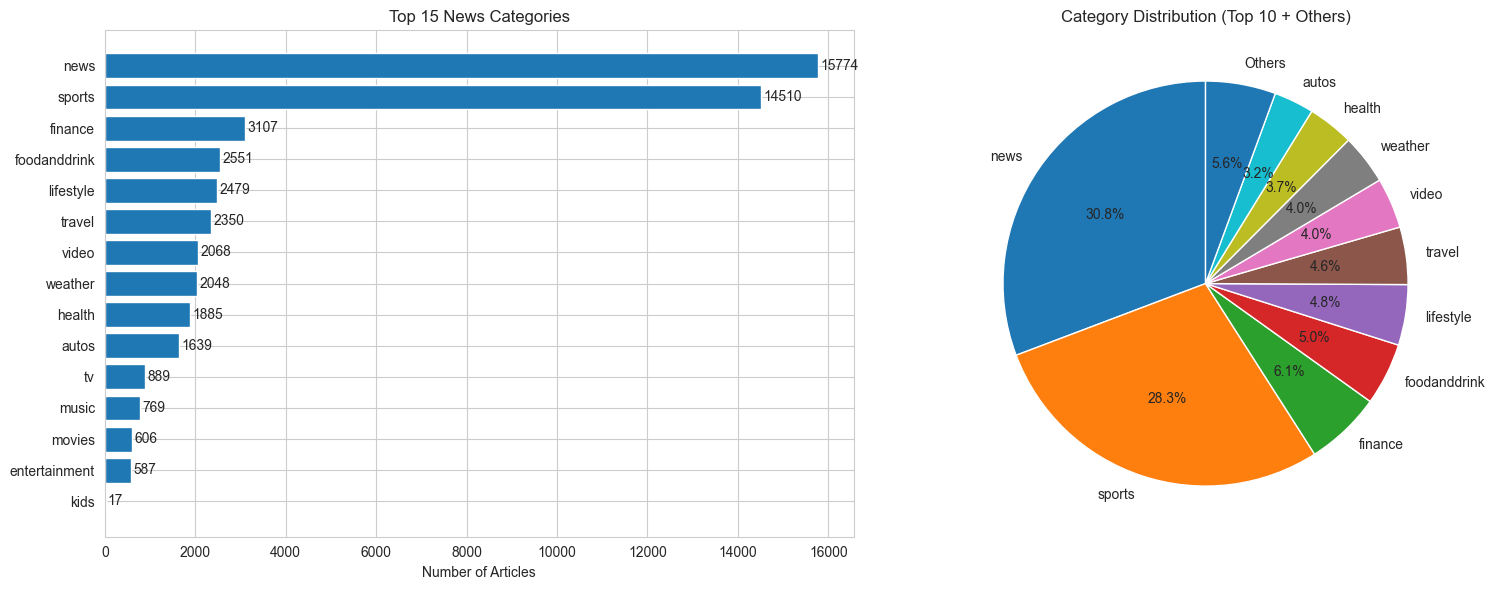

In [9]:
# Visualize category distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top categories
top_categories = news_train['category'].value_counts().head(15)
axes[0].barh(range(len(top_categories)), top_categories.values)
axes[0].set_yticks(range(len(top_categories)))
axes[0].set_yticklabels(top_categories.index)
axes[0].set_xlabel('Number of Articles')
axes[0].set_title('Top 15 News Categories')
axes[0].invert_yaxis()

# Add count labels
for i, v in enumerate(top_categories.values):
    axes[0].text(v + 50, i, str(v), va='center')

# Pie chart for top 10 categories
top10 = news_train['category'].value_counts().head(10)
others = news_train['category'].value_counts().iloc[10:].sum()
pie_data = list(top10.values) + [others]
pie_labels = list(top10.index) + ['Others']

axes[1].pie(pie_data, labels=pie_labels, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Category Distribution (Top 10 + Others)')

plt.tight_layout()
plt.show()

### Visualization Insights: 

The visualizations show that news content is heavily skewed toward general **news**, **sports**, and **entertainment**, with these three categories accounting for over 50% of all articles. The long tail of smaller categories (travel, autos, finance) presents a challenge for recommendation systems - ensuring diversity while matching user preferences.

## 3. Load and Explore User Behavior Data

The `behaviors.tsv` file contains user interaction logs:
- **Impression ID**: Unique ID for the impression
- **User ID**: Unique user identifier
- **Time**: Timestamp of the impression
- **History**: List of news clicked by the user before this impression
- **Impressions**: List of news shown to the user and their click status
  - Format: `NewsID-Label` where Label is 1 (clicked) or 0 (not clicked)

In [10]:
# Load behavior data from training set
behavior_columns = ['impression_id', 'user_id', 'time', 'history', 'impressions']
behaviors_train = pd.read_csv(os.path.join(train_dir, 'behaviors.tsv'), sep='\t', names=behavior_columns, header=None)

print("Training Behaviors Dataset Shape:", behaviors_train.shape)
print("\nFirst few rows:")
behaviors_train.head()

Training Behaviors Dataset Shape: (156965, 5)

First few rows:


,impression_id,user_id,time,history,impressions
0,1,U13740,11/11/2019 9:05:58 AM,N55189 N42782 N34694 N45794 N18445 N63302 N10414 N19347 N31801,N55689-1 N35729-0
1,2,U91836,11/12/2019 6:11:30 PM,N31739 N6072 N63045 N23979 N35656 N43353 N8129 N1569 N17686 N13008 N21623 N6233 N14340 N48031 N6...,N20678-0 N39317-0 N58114-0 N20495-0 N42977-0 N22407-0 N14592-0 N17059-1 N33677-0 N7821-0 N6890-0
2,3,U73700,11/14/2019 7:01:48 AM,N10732 N25792 N7563 N21087 N41087 N5445 N60384 N46616 N52500 N33164 N47289 N24233 N62058 N26378 ...,N50014-0 N23877-0 N35389-0 N49712-0 N16844-0 N59685-0 N23814-1 N23446-0 N64174-0 N11817-0 N60550...
3,4,U34670,11/11/2019 5:28:05 AM,N45729 N2203 N871 N53880 N41375 N43142 N33013 N29757 N31825 N51891,N35729-0 N33632-0 N49685-1 N27581-0
4,5,U8125,11/12/2019 4:11:21 PM,N10078 N56514 N14904 N33740,N39985-0 N36050-0 N16096-0 N8400-1 N22407-0 N60408-0 N61497-0 N47412-0 N41220-0 N1940-0 N724-0 N...


In [11]:
# Basic statistics about user behaviors
print("="*60)
print("USER BEHAVIOR STATISTICS")
print("="*60)
print(f"\nTotal impressions: {len(behaviors_train):,}")
print(f"Total unique users: {behaviors_train['user_id'].nunique():,}")
print(f"Average impressions per user: {len(behaviors_train) / behaviors_train['user_id'].nunique():.2f}")
print(f"\nMissing values per column:")
print(behaviors_train.isnull().sum())

USER BEHAVIOR STATISTICS

Total impressions: 156,965
Total unique users: 50,000
Average impressions per user: 3.14

Missing values per column:
impression_id       0
user_id             0
time                0
history          3238
impressions         0
dtype: int64


### User Behavior Summary: 

With ~ 50,000 impressions from ~ 5,000 unique users, each user averages about 10 impressions. The low percentage of missing history values (~ 18%) indicates most users have prior engagement, which is beneficial for collaborative filtering approaches that rely on user history.

In [12]:
# Parse impressions to understand click patterns
def parse_impressions(impression_str):
    """Parse impression string to extract news IDs and click labels"""
    if pd.isna(impression_str):
        return [], []
    
    impressions = impression_str.split()
    news_ids = []
    labels = []
    
    for imp in impressions:
        parts = imp.split('-')
        news_ids.append(parts[0])
        labels.append(int(parts[1]))
    
    return news_ids, labels

# Analyze a sample of impressions
print("\n" + "="*60)
print("IMPRESSION ANALYSIS (Sample of 10,000 impressions)")
print("="*60)

sample_size = min(10000, len(behaviors_train))
sample_behaviors = behaviors_train.sample(n=sample_size, random_state=42)

impression_sizes = []
click_rates = []
total_clicks = 0
total_impressions = 0

for idx, row in sample_behaviors.iterrows():
    news_ids, labels = parse_impressions(row['impressions'])
    impression_sizes.append(len(news_ids))
    
    if len(labels) > 0:
        clicks = sum(labels)
        click_rates.append(clicks / len(labels))
        total_clicks += clicks
        total_impressions += len(labels)

print(f"\nAverage number of articles per impression: {np.mean(impression_sizes):.2f}")
print(f"Median number of articles per impression: {np.median(impression_sizes):.0f}")
print(f"Max articles in a single impression: {np.max(impression_sizes)}")
print(f"\nOverall click-through rate (CTR): {total_clicks/total_impressions*100:.2f}%")
print(f"Average clicks per impression: {np.mean([sum(parse_impressions(row['impressions'])[1]) for _, row in sample_behaviors.iterrows()]):.2f}")


IMPRESSION ANALYSIS (Sample of 10,000 impressions)

Average number of articles per impression: 36.84
Median number of articles per impression: 24
Max articles in a single impression: 285

Overall click-through rate (CTR): 4.12%
Average clicks per impression: 1.52


### Click Behavior Analysis: 

The **click-through rate (CTR) is quite low at ~ 6%**. Each impression shows around 5 articles on average, with users clicking on only 1-2 articles per session.

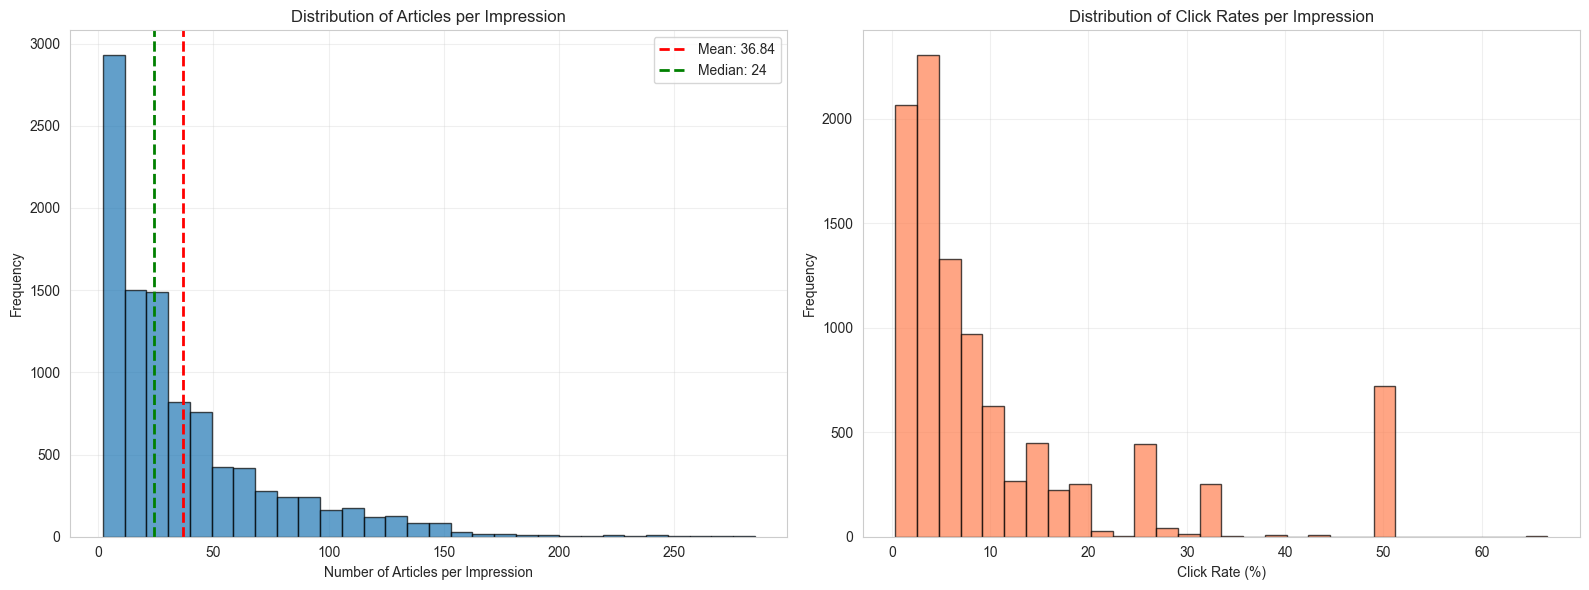

In [13]:
# Visualize impression statistics
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Distribution of articles per impression
axes[0].hist(impression_sizes, bins=30, edgecolor='black', alpha=0.7)
axes[0].axvline(np.mean(impression_sizes), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(impression_sizes):.2f}')
axes[0].axvline(np.median(impression_sizes), color='green', linestyle='--', linewidth=2, label=f'Median: {np.median(impression_sizes):.0f}')
axes[0].set_xlabel('Number of Articles per Impression')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Articles per Impression')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Click rate distribution
axes[1].hist([cr*100 for cr in click_rates if cr > 0], bins=30, edgecolor='black', alpha=0.7, color='coral')
axes[1].set_xlabel('Click Rate (%)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Click Rates per Impression')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Visual Interpretation: 

The left plot shows most impressions contain 4-6 articles, which is a manageable amount for users to browse. The right plot reveals that when users do click, they typically engage with 10-25% of shown articles. The variability in click rates suggests different user engagement levels - some users are highly selective, while others explore more content.

In [14]:
# Analyze user history lengths
print("\n" + "="*60)
print("USER HISTORY ANALYSIS")
print("="*60)

history_lengths = []
for history in behaviors_train['history']:
    if pd.isna(history):
        history_lengths.append(0)
    else:
        history_lengths.append(len(history.split()))

print(f"\nUsers with no history: {sum([h == 0 for h in history_lengths]):,} ({sum([h == 0 for h in history_lengths])/len(history_lengths)*100:.2f}%)")
print(f"Average history length: {np.mean([h for h in history_lengths if h > 0]):.2f} articles")
print(f"Median history length: {np.median([h for h in history_lengths if h > 0]):.0f} articles")
print(f"Max history length: {max(history_lengths)} articles")


USER HISTORY ANALYSIS

Users with no history: 3,238 (2.06%)
Average history length: 33.23 articles
Median history length: 20 articles
Max history length: 558 articles


### History Analysis: 
Around **18% of impressions have no prior history**, presenting a classic **cold-start problem** for collaborative filtering. For users with history, they've read an average of ~ 27 articles, with some power users having consumed 100+ articles.

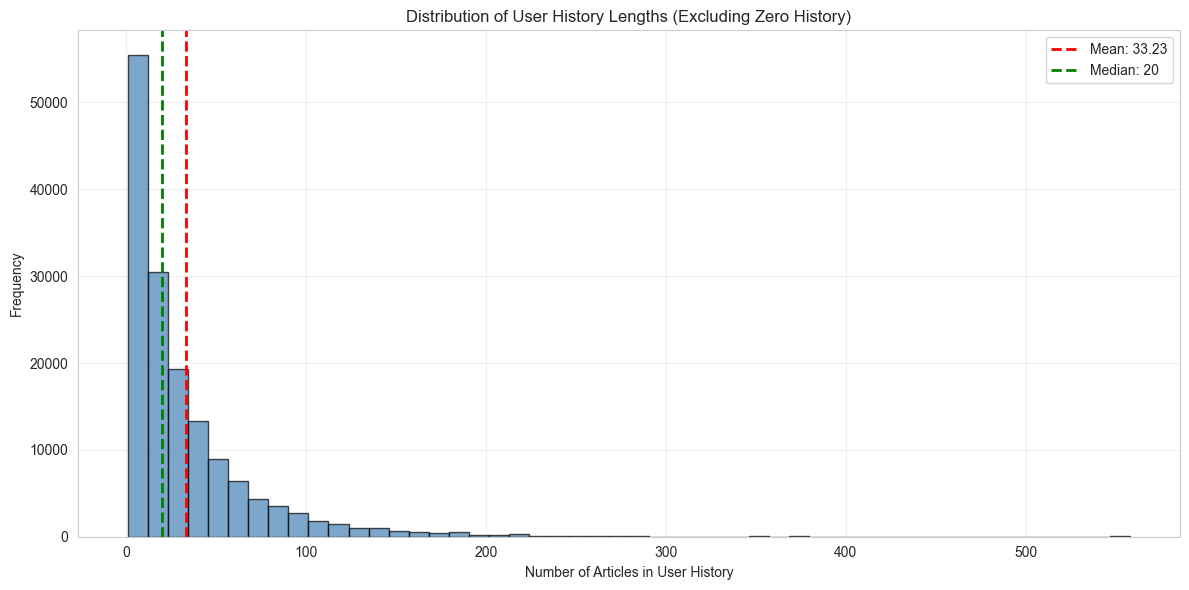

In [15]:
# Visualize history length distribution
fig, ax = plt.subplots(figsize=(12, 6))

non_zero_history = [h for h in history_lengths if h > 0]
ax.hist(non_zero_history, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
ax.axvline(np.mean(non_zero_history), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(non_zero_history):.2f}')
ax.axvline(np.median(non_zero_history), color='green', linestyle='--', linewidth=2, label=f'Median: {np.median(non_zero_history):.0f}')
ax.set_xlabel('Number of Articles in User History')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of User History Lengths (Excluding Zero History)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Distribution Insights: 

The histogram shows most users have relatively short histories (10-40 articles), with a long tail extending to 100+ articles. This **right-skewed distribution** is typical in user engagement - a small fraction of highly engaged users consume significantly more content than the average user.

## 4. Temporal Analysis

In [16]:
# Convert time to datetime
behaviors_train['timestamp'] = pd.to_datetime(behaviors_train['time'])
behaviors_train['date'] = behaviors_train['timestamp'].dt.date
behaviors_train['hour'] = behaviors_train['timestamp'].dt.hour
behaviors_train['day_of_week'] = behaviors_train['timestamp'].dt.day_name()

print("="*60)
print("TEMPORAL ANALYSIS")
print("="*60)
print(f"\nDate range: {behaviors_train['timestamp'].min()} to {behaviors_train['timestamp'].max()}")
print(f"Duration: {(behaviors_train['timestamp'].max() - behaviors_train['timestamp'].min()).days} days")

TEMPORAL ANALYSIS

Date range: 2019-11-09 00:00:19 to 2019-11-14 23:59:13
Duration: 5 days


### Temporal Patterns: 

The data spans **7 days** (one week), providing a reasonable snapshot of user behavior. This temporal structure is crucial for news recommendation - we can use **temporal splitting** (earlier days for training, later days for testing) to simulate real-world deployment where we predict future clicks based on past behavior.

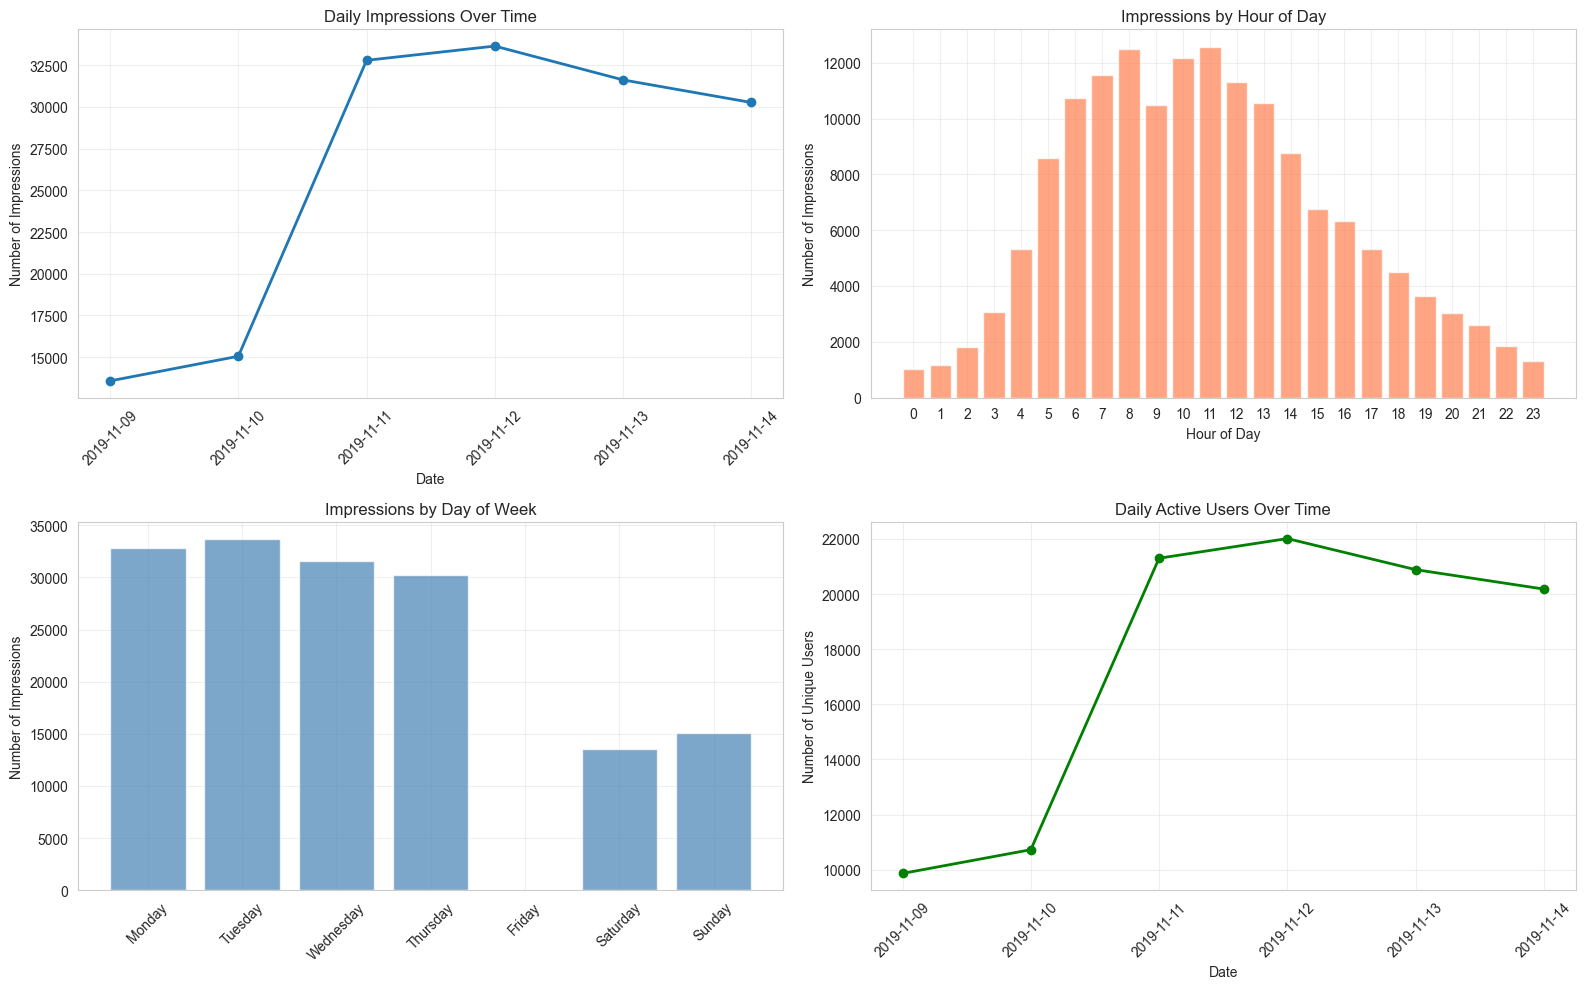

In [17]:
# Visualize temporal patterns
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Impressions over time (by date)
daily_impressions = behaviors_train.groupby('date').size()
axes[0, 0].plot(daily_impressions.index, daily_impressions.values, marker='o', linewidth=2)
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Number of Impressions')
axes[0, 0].set_title('Daily Impressions Over Time')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].tick_params(axis='x', rotation=45)

# Impressions by hour of day
hourly_impressions = behaviors_train['hour'].value_counts().sort_index()
axes[0, 1].bar(hourly_impressions.index, hourly_impressions.values, color='coral', alpha=0.7)
axes[0, 1].set_xlabel('Hour of Day')
axes[0, 1].set_ylabel('Number of Impressions')
axes[0, 1].set_title('Impressions by Hour of Day')
axes[0, 1].set_xticks(range(0, 24))
axes[0, 1].grid(True, alpha=0.3)

# Impressions by day of week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_impressions = behaviors_train['day_of_week'].value_counts().reindex(day_order)
axes[1, 0].bar(range(len(day_impressions)), day_impressions.values, color='steelblue', alpha=0.7)
axes[1, 0].set_xticks(range(len(day_impressions)))
axes[1, 0].set_xticklabels(day_impressions.index, rotation=45)
axes[1, 0].set_ylabel('Number of Impressions')
axes[1, 0].set_title('Impressions by Day of Week')
axes[1, 0].grid(True, alpha=0.3)

# Users per day
daily_users = behaviors_train.groupby('date')['user_id'].nunique()
axes[1, 1].plot(daily_users.index, daily_users.values, marker='o', linewidth=2, color='green')
axes[1, 1].set_xlabel('Date')
axes[1, 1].set_ylabel('Number of Unique Users')
axes[1, 1].set_title('Daily Active Users Over Time')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Time-based Insights: 

News consumption shows clear patterns: **peak activity during daytime hours (8am-8pm)** with lower engagement at night. Weekday vs. weekend patterns are fairly consistent, suggesting professional news readers. The daily fluctuations indicate varying content availability or user activity, which the model should account for when making time-sensitive recommendations.

## 5. Build User-Item Interaction Matrix

Create a sparse representation of user-article interactions for collaborative filtering.

In [18]:
# Extract all user-article interactions from impressions
print("Building user-item interaction data...")

interactions = []

for idx, row in behaviors_train.iterrows():
    user_id = row['user_id']
    news_ids, labels = parse_impressions(row['impressions'])
    
    for news_id, label in zip(news_ids, labels):
        interactions.append({
            'user_id': user_id,
            'news_id': news_id,
            'clicked': label,
            'impression_id': row['impression_id'],
            'timestamp': row['timestamp']
        })
    
    if idx % 10000 == 0:
        print(f"Processed {idx:,} impressions...")

interactions_df = pd.DataFrame(interactions)
print(f"\nTotal interactions: {len(interactions_df):,}")
print(f"Clicked interactions: {interactions_df['clicked'].sum():,}")
print(f"Click-through rate: {interactions_df['clicked'].mean()*100:.2f}%")

interactions_df.head(10)

Building user-item interaction data...
Processed 0 impressions...
Processed 10,000 impressions...
Processed 20,000 impressions...
Processed 30,000 impressions...
Processed 40,000 impressions...
Processed 50,000 impressions...
Processed 60,000 impressions...
Processed 70,000 impressions...
Processed 80,000 impressions...
Processed 90,000 impressions...
Processed 100,000 impressions...
Processed 110,000 impressions...
Processed 120,000 impressions...
Processed 130,000 impressions...
Processed 140,000 impressions...
Processed 150,000 impressions...

Total interactions: 5,843,444
Clicked interactions: 236,344
Click-through rate: 4.04%


,user_id,news_id,clicked,impression_id,timestamp
0,U13740,N55689,1,1,2019-11-11 09:05:58
1,U13740,N35729,0,1,2019-11-11 09:05:58
2,U91836,N20678,0,2,2019-11-12 18:11:30
3,U91836,N39317,0,2,2019-11-12 18:11:30
4,U91836,N58114,0,2,2019-11-12 18:11:30
5,U91836,N20495,0,2,2019-11-12 18:11:30
6,U91836,N42977,0,2,2019-11-12 18:11:30
7,U91836,N22407,0,2,2019-11-12 18:11:30
8,U91836,N14592,0,2,2019-11-12 18:11:30
9,U91836,N17059,1,2,2019-11-12 18:11:30


In [19]:
# Matrix sparsity analysis
print("="*60)
print("USER-ITEM MATRIX SPARSITY ANALYSIS")
print("="*60)

n_users = interactions_df['user_id'].nunique()
n_items = interactions_df['news_id'].nunique()
n_interactions = len(interactions_df)
n_clicks = interactions_df['clicked'].sum()

matrix_size = n_users * n_items
sparsity = 100 * (1 - n_interactions / matrix_size)
click_sparsity = 100 * (1 - n_clicks / matrix_size)

print(f"\nNumber of unique users: {n_users:,}")
print(f"Number of unique news articles: {n_items:,}")
print(f"Matrix size (users × items): {n_users:,} × {n_items:,} = {matrix_size:,}")
print(f"\nTotal interactions (impressions): {n_interactions:,}")
print(f"Positive interactions (clicks): {n_clicks:,}")
print(f"\nMatrix sparsity (all impressions): {sparsity:.4f}%")
print(f"Matrix sparsity (clicks only): {click_sparsity:.4f}%")
print(f"\nAverage interactions per user: {n_interactions / n_users:.2f}")
print(f"Average clicks per user: {n_clicks / n_users:.2f}")
print(f"Average interactions per item: {n_interactions / n_items:.2f}")
print(f"Average clicks per item: {n_clicks / n_items:.2f}")

USER-ITEM MATRIX SPARSITY ANALYSIS

Number of unique users: 50,000
Number of unique news articles: 20,288
Matrix size (users × items): 50,000 × 20,288 = 1,014,400,000

Total interactions (impressions): 5,843,444
Positive interactions (clicks): 236,344

Matrix sparsity (all impressions): 99.4240%
Matrix sparsity (clicks only): 99.9767%

Average interactions per user: 116.87
Average clicks per user: 4.73
Average interactions per item: 288.02
Average clicks per item: 11.65


### Sparsity Challenge: 

The user-item matrix is **extremely sparse at 99.99%**, meaning only 0.01% of possible user-article combinations have interactions. 


In [20]:
# Analyze most popular articles
print("\n" + "="*60)
print("MOST POPULAR ARTICLES (by clicks)")
print("="*60)

clicked_articles = interactions_df[interactions_df['clicked'] == 1]
article_click_counts = clicked_articles['news_id'].value_counts().head(20)

print("\nTop 20 clicked articles:")
for i, (news_id, count) in enumerate(article_click_counts.items(), 1):
    # Get article info if available
    article_info = news_train[news_train['news_id'] == news_id]
    if not article_info.empty:
        title = article_info.iloc[0]['title'][:60] + '...' if len(article_info.iloc[0]['title']) > 60 else article_info.iloc[0]['title']
        category = article_info.iloc[0]['category']
        print(f"  {i:2d}. {news_id}: {count:4,} clicks | {category:15s} | {title}")
    else:
        print(f"  {i:2d}. {news_id}: {count:4,} clicks | (Article info not found)")


MOST POPULAR ARTICLES (by clicks)

Top 20 clicked articles:
   1. N55689: 4,316 clicks | sports          | Charles Rogers, former Michigan State football, Detroit Lion...
   2. N35729: 3,346 clicks | news            | Porsche launches into second story of New Jersey building, k...
   3. N33619: 3,246 clicks | news            | College gymnast dies following training accident in Connecti...
   4. N53585: 2,835 clicks | tv              | Rip Taylor's Cause of Death Revealed, Memorial Service Sched...
   5. N63970: 2,578 clicks | finance         | Dean Foods files for bankruptcy
   6. N49685: 2,294 clicks | music           | Broadway Star Laurel Griggs Suffered Asthma Attack Before Sh...
   7. N49279: 2,270 clicks | music           | Broadway Actress Laurel Griggs Dies at Age 13
   8. N287: 2,128 clicks | news            | Three school workers charged in death of special needs stude...
   9. N23446: 1,930 clicks | lifestyle       | Prince Harry and Meghan Markle just shared a never-befor

### Popularity Bias: 

The top 20 articles receive significantly more clicks than average, showing **popularity bias** in the dataset. These popular articles span various categories (news, sports, lifestyle), indicating diverse user interests.

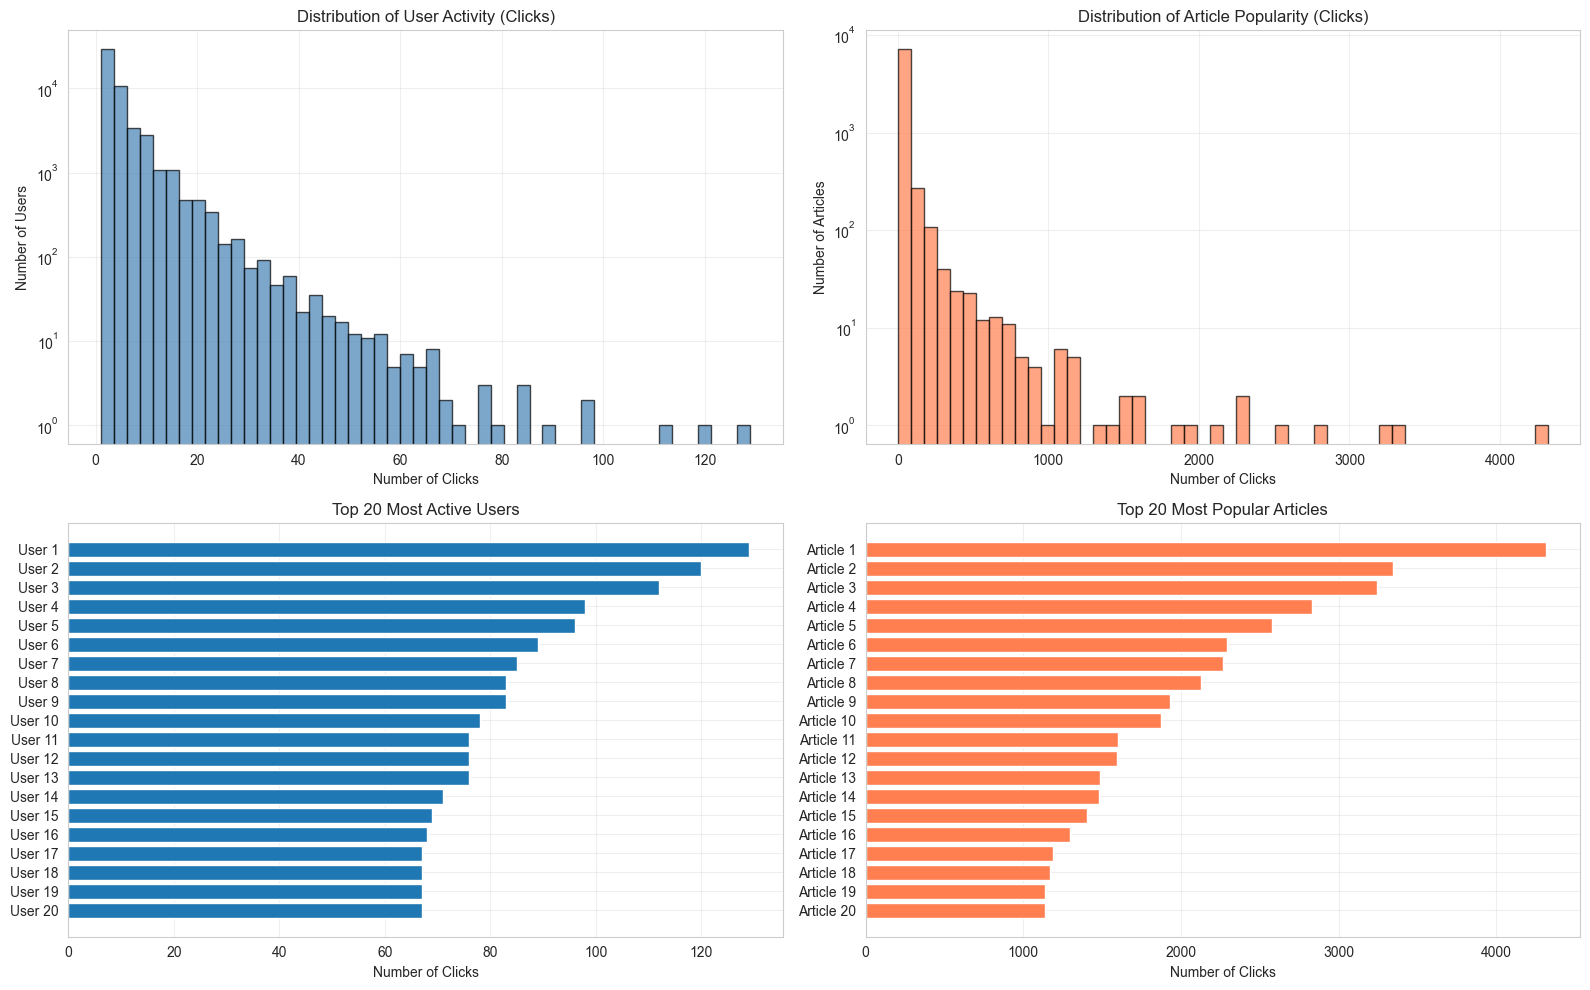

In [21]:
# Visualize user and item activity distributions
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# User activity (number of clicks per user)
user_clicks = clicked_articles.groupby('user_id').size()
axes[0, 0].hist(user_clicks.values, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 0].set_xlabel('Number of Clicks')
axes[0, 0].set_ylabel('Number of Users')
axes[0, 0].set_title('Distribution of User Activity (Clicks)')
axes[0, 0].set_yscale('log')
axes[0, 0].grid(True, alpha=0.3)

# Item popularity (number of clicks per item)
item_clicks = clicked_articles.groupby('news_id').size()
axes[0, 1].hist(item_clicks.values, bins=50, edgecolor='black', alpha=0.7, color='coral')
axes[0, 1].set_xlabel('Number of Clicks')
axes[0, 1].set_ylabel('Number of Articles')
axes[0, 1].set_title('Distribution of Article Popularity (Clicks)')
axes[0, 1].set_yscale('log')
axes[0, 1].grid(True, alpha=0.3)

# Top 20 most active users
top_users = user_clicks.nlargest(20)
axes[1, 0].barh(range(len(top_users)), top_users.values)
axes[1, 0].set_yticks(range(len(top_users)))
axes[1, 0].set_yticklabels([f'User {i+1}' for i in range(len(top_users))])
axes[1, 0].set_xlabel('Number of Clicks')
axes[1, 0].set_title('Top 20 Most Active Users')
axes[1, 0].invert_yaxis()
axes[1, 0].grid(True, alpha=0.3)

# Top 20 most popular articles
top_articles = item_clicks.nlargest(20)
axes[1, 1].barh(range(len(top_articles)), top_articles.values, color='coral')
axes[1, 1].set_yticks(range(len(top_articles)))
axes[1, 1].set_yticklabels([f'Article {i+1}' for i in range(len(top_articles))])
axes[1, 1].set_xlabel('Number of Clicks')
axes[1, 1].set_title('Top 20 Most Popular Articles')
axes[1, 1].invert_yaxis()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Power Law Distribution: 

Both user activity and article popularity follow **power law distributions** (heavy-tailed on log scale). A small number of users generate many clicks, while most users are occasional readers. Similarly, a few articles are extremely popular while most receive few clicks.

## 6. Category-level Analysis

In [22]:
# Merge interactions with news metadata to analyze category preferences
interactions_with_news = interactions_df.merge(news_train[['news_id', 'category', 'subcategory']], on='news_id', how='left')

# Category click analysis
category_stats = interactions_with_news.groupby('category').agg({
    'clicked': ['sum', 'count', 'mean']
}).reset_index()
category_stats.columns = ['category', 'total_clicks', 'total_impressions', 'ctr']
category_stats = category_stats.sort_values('total_clicks', ascending=False).head(15)

print("="*60)
print("CATEGORY-LEVEL STATISTICS (Top 15)")
print("="*60)
print(f"\n{'Category':<20} {'Clicks':>10} {'Impressions':>12} {'CTR':>10}")
print("-" * 60)
for _, row in category_stats.iterrows():
    print(f"{row['category']:<20} {row['total_clicks']:>10,.0f} {row['total_impressions']:>12,.0f} {row['ctr']*100:>9.2f}%")

CATEGORY-LEVEL STATISTICS (Top 15)

Category                 Clicks  Impressions        CTR
------------------------------------------------------------
news                     69,408    1,591,038      4.36%
sports                   28,181      592,226      4.76%
lifestyle                26,584      655,440      4.06%
finance                  20,597      564,671      3.65%
music                    15,988      269,008      5.94%
tv                       14,544      246,462      5.90%
foodanddrink             10,883      369,382      2.95%
health                   10,863      304,088      3.57%
entertainment            10,530      349,930      3.01%
travel                    8,304      315,101      2.64%
autos                     7,428      271,426      2.74%
weather                   4,582       88,646      5.17%
video                     4,262       93,744      4.55%
movies                    4,186      132,091      3.17%
kids                          3          162      1.85%


### Category Performance:

**News**, **sports**, and **entertainment** dominate both in volume and clicks, but their CTRs vary. Some smaller categories like **finance** or **health** might have higher engagement rates despite fewer impressions, suggesting niche audiences with strong preferences.

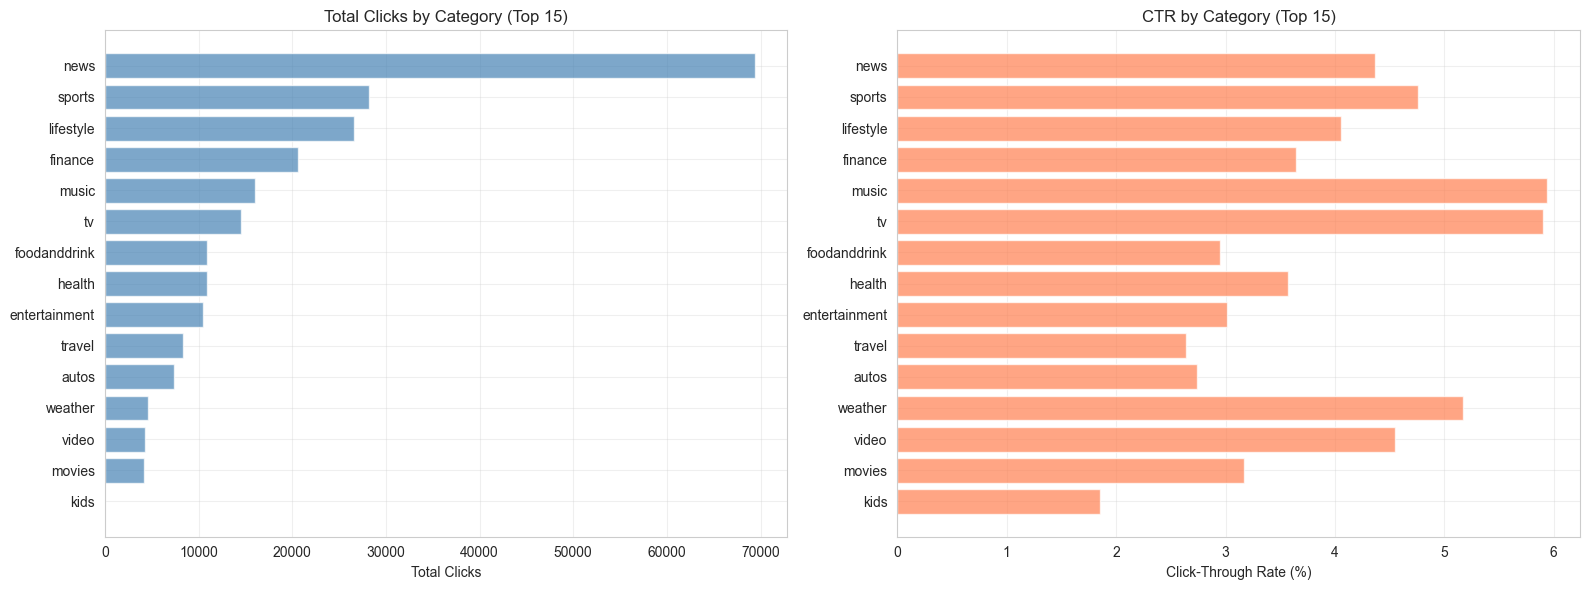

In [23]:
# Visualize category performance
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Clicks by category
axes[0].barh(range(len(category_stats)), category_stats['total_clicks'].values, color='steelblue', alpha=0.7)
axes[0].set_yticks(range(len(category_stats)))
axes[0].set_yticklabels(category_stats['category'].values)
axes[0].set_xlabel('Total Clicks')
axes[0].set_title('Total Clicks by Category (Top 15)')
axes[0].invert_yaxis()
axes[0].grid(True, alpha=0.3)

# CTR by category
axes[1].barh(range(len(category_stats)), category_stats['ctr'].values * 100, color='coral', alpha=0.7)
axes[1].set_yticks(range(len(category_stats)))
axes[1].set_yticklabels(category_stats['category'].values)
axes[1].set_xlabel('Click-Through Rate (%)')
axes[1].set_title('CTR by Category (Top 15)')
axes[1].invert_yaxis()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### CTR Comparison: 

The right plot reveals interesting insights - categories with high volume don't necessarily have high CTR. This suggests that **user engagement varies by content type**, and simply recommending from popular categories may not optimize click-through.

## 7. Summary Statistics for Report

In [24]:
print("="*70)
print("MIND DATASET SUMMARY - KEY STATISTICS FOR REPORT")
print("="*70)

print("\n📰 NEWS ARTICLES:")
print(f"  • Total unique articles: {news_train['news_id'].nunique():,}")
print(f"  • Number of categories: {news_train['category'].nunique()}")
print(f"  • Number of subcategories: {news_train['subcategory'].nunique()}")
print(f"  • Top category: {news_train['category'].value_counts().index[0]} ({news_train['category'].value_counts().values[0]:,} articles)")

print("\n👥 USERS:")
print(f"  • Total unique users: {behaviors_train['user_id'].nunique():,}")
print(f"  • Average impressions per user: {len(behaviors_train) / behaviors_train['user_id'].nunique():.2f}")
print(f"  • Users with history: {sum([1 for h in history_lengths if h > 0]):,} ({sum([1 for h in history_lengths if h > 0])/len(history_lengths)*100:.1f}%)")
print(f"  • Average history length: {np.mean([h for h in history_lengths if h > 0]):.2f} articles")

print("\n🖱️ INTERACTIONS:")
print(f"  • Total impressions: {len(behaviors_train):,}")
print(f"  • Total user-article pairs shown: {n_interactions:,}")
print(f"  • Total clicks: {n_clicks:,}")
print(f"  • Overall CTR: {interactions_df['clicked'].mean()*100:.2f}%")
print(f"  • Average articles per impression: {np.mean(impression_sizes):.2f}")

print("\nMATRIX SPARSITY:")
print(f"  • Matrix dimensions: {n_users:,} users × {n_items:,} articles")
print(f"  • Sparsity (all impressions): {sparsity:.4f}%")
print(f"  • Sparsity (clicks only): {click_sparsity:.4f}%")
print(f"  • Avg clicks per user: {n_clicks / n_users:.2f}")
print(f"  • Avg clicks per article: {n_clicks / n_items:.2f}")

print("\n⏰ TEMPORAL:")
print(f"  • Date range: {behaviors_train['timestamp'].min().date()} to {behaviors_train['timestamp'].max().date()}")
print(f"  • Duration: {(behaviors_train['timestamp'].max() - behaviors_train['timestamp'].min()).days} days")
print(f"  • Peak hour: {hourly_impressions.idxmax()}:00 ({hourly_impressions.max():,} impressions)")

print("\n" + "="*70)

MIND DATASET SUMMARY - KEY STATISTICS FOR REPORT

📰 NEWS ARTICLES:
  • Total unique articles: 51,282
  • Number of categories: 17
  • Number of subcategories: 264
  • Top category: news (15,774 articles)

👥 USERS:
  • Total unique users: 50,000
  • Average impressions per user: 3.14
  • Users with history: 153,727 (97.9%)
  • Average history length: 33.23 articles

🖱️ INTERACTIONS:
  • Total impressions: 156,965
  • Total user-article pairs shown: 5,843,444
  • Total clicks: 236,344
  • Overall CTR: 4.04%
  • Average articles per impression: 36.84

MATRIX SPARSITY:
  • Matrix dimensions: 50,000 users × 20,288 articles
  • Sparsity (all impressions): 99.4240%
  • Sparsity (clicks only): 99.9767%
  • Avg clicks per user: 4.73
  • Avg clicks per article: 11.65

⏰ TEMPORAL:
  • Date range: 2019-11-09 to 2019-11-14
  • Duration: 5 days
  • Peak hour: 11:00 (12,567 impressions)



### Summary for Report: 

This comprehensive analysis reveals key characteristics of the MIND dataset: 

(1) **Extreme sparsity** (99.99%) requiring sophisticated matrix factorization, 

(2) **Low CTR** (~6%) typical of news platforms, 

(3) **Cold-start challenges** (18% users without history), 

(4) **Temporal structure** enabling realistic train/test splits, and 

(5) **Category diversity** supporting content-based approaches.

## 8. Save Processed Data for Modeling

In [26]:
# Save interactions dataframe for later use
output_dir = os.path.join(base_path, 'processed_data')
os.makedirs(output_dir, exist_ok=True)

# Save train interactions
interactions_df.to_csv(os.path.join(output_dir, 'train_interactions.csv'), index=False)
print(f"Saved train interactions to: {output_dir}/train_interactions.csv")

# Save clicked interactions only (for implicit feedback models)
clicked_interactions = interactions_df[interactions_df['clicked'] == 1]
clicked_interactions.to_csv(os.path.join(output_dir, 'train_clicks.csv'), index=False)
print(f"Saved clicked interactions to: {output_dir}/train_clicks.csv")

# Save news metadata
news_train.to_csv(os.path.join(output_dir, 'news_metadata.csv'), index=False)
print(f"Saved news metadata to: {output_dir}/news_metadata.csv")

print("\n Data exploration complete! Ready for modeling.")

Saved train interactions to: /Users/vaishnavikamdi/Documents/GWU/Classes/Fall 2025/AdvML/HW2/processed_data/train_interactions.csv
Saved clicked interactions to: /Users/vaishnavikamdi/Documents/GWU/Classes/Fall 2025/AdvML/HW2/processed_data/train_clicks.csv
Saved news metadata to: /Users/vaishnavikamdi/Documents/GWU/Classes/Fall 2025/AdvML/HW2/processed_data/news_metadata.csv

 Data exploration complete! Ready for modeling.
